Loaded baseline_df:
   mo_yr       date  ALABAMA        ALASKA  ARIZONA  CALIFORNIA  COLORADO  \
0    397 2009-01-01     3.76 -1.800001e-01     3.12        3.64      1.10   
1    398 2009-02-01     4.74  2.864000e-07     3.56        4.24      1.50   
2    399 2009-03-01     5.04  3.000003e-01     3.78        4.46      1.70   
3    400 2009-04-01     5.12  4.400002e-01     3.84        4.44      1.84   
4    401 2009-05-01     5.76  6.199999e-01     4.32        4.98      2.14   

   CONNECTICUT  DELAWARE  DISTRICT OF COLUMBIA  ...  VERMONT  VIRGINIA  \
0         2.48      3.24                  1.26  ...     2.36      2.10   
1         2.70      3.66                  1.54  ...     2.78      2.42   
2         2.88      3.92                  1.74  ...     3.24      2.70   
3         3.06      4.14                  2.10  ...     3.40      2.64   
4         3.08      4.44                  2.34  ...     3.38      3.00   

   WASHINGTON  WEST VIRGINIA  WISCONSIN  WYOMING  synthetic_baseline  tr

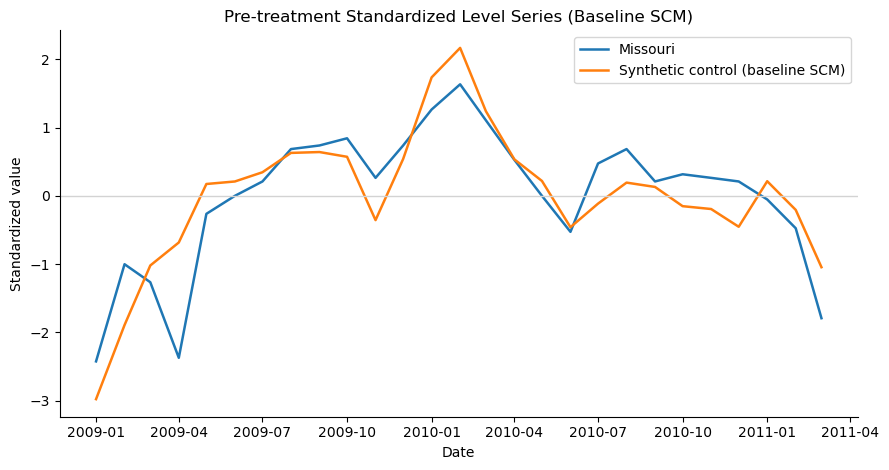


Running baseline embedding (3,1)
treated point cloud shape  : (25, 3)
synthetic point cloud shape: (25, 3)


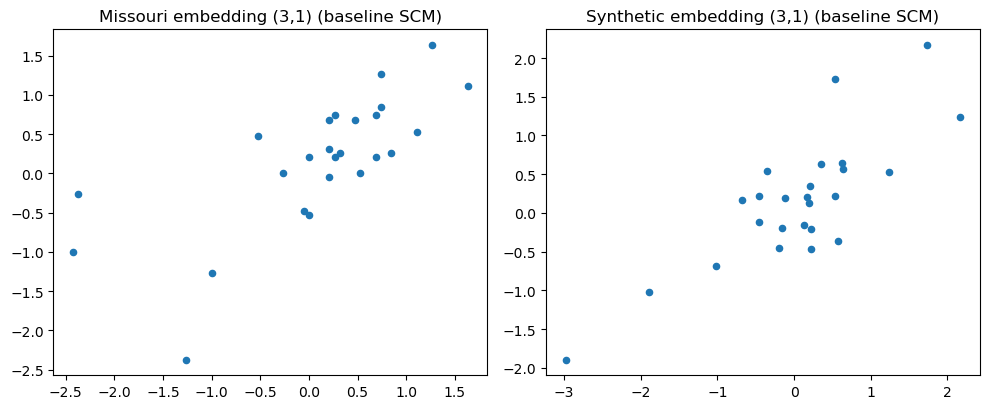

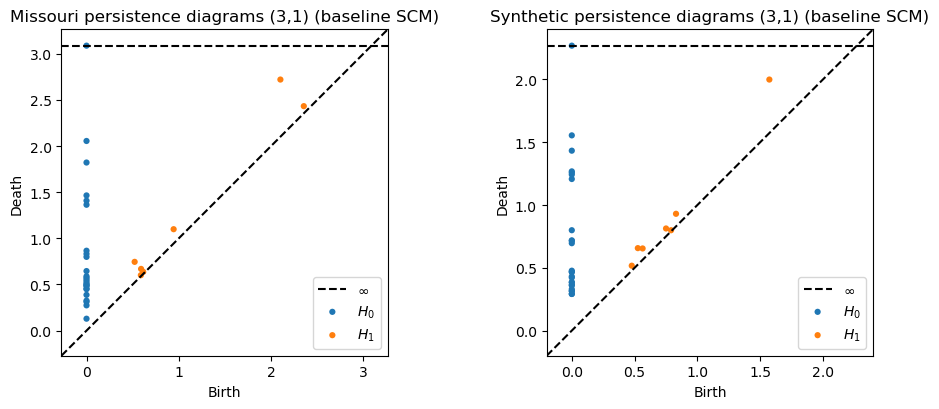

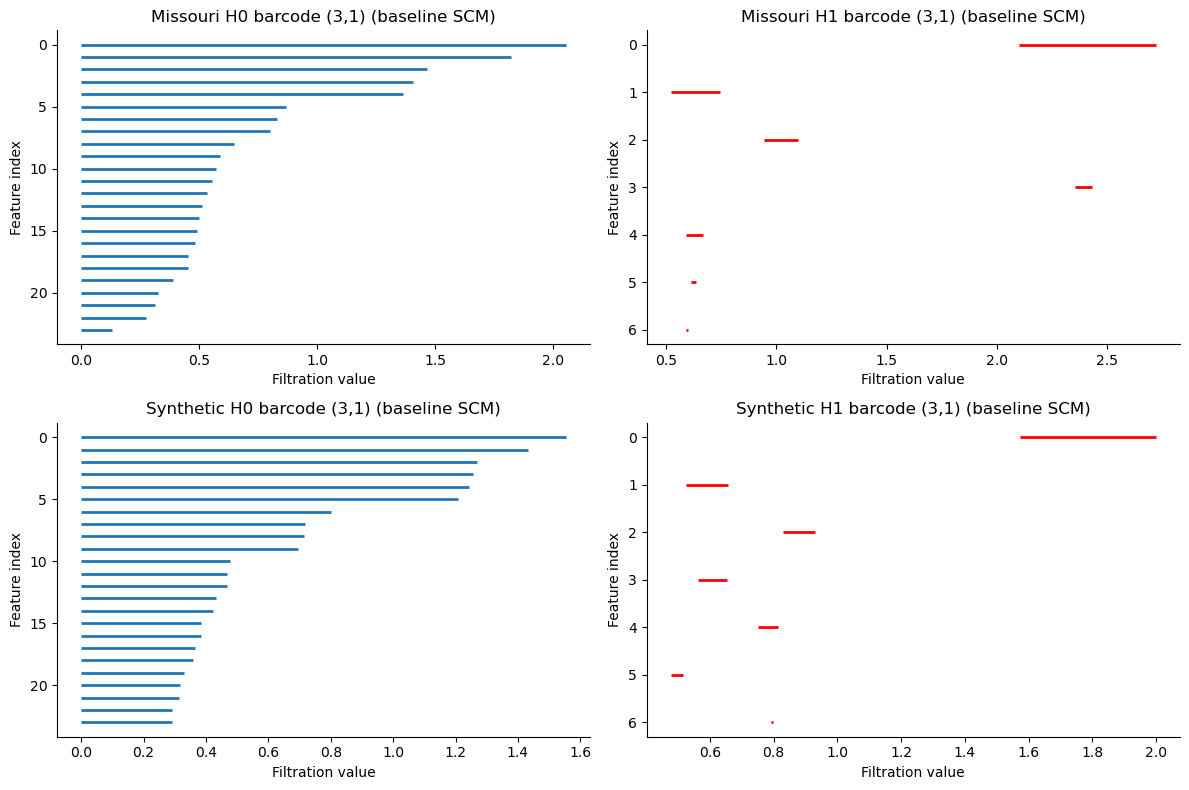


Baseline embedding (3,1) summaries
Missouri H0: {'n_features': 24, 'max_persistence': 2.055481433868408, 'total_persistence': 17.81806281208992, 'mean_persistence': 0.74241928383708}
Missouri H1: {'n_features': 7, 'max_persistence': 0.6197268962860107, 'total_persistence': 1.1870372295379639, 'mean_persistence': 0.16957674707685197}
Synthetic H0: {'n_features': 24, 'max_persistence': 1.554653525352478, 'total_persistence': 16.193736493587494, 'mean_persistence': 0.6747390205661455}
Synthetic H1: {'n_features': 7, 'max_persistence': 0.4260373115539551, 'total_persistence': 0.858764111995697, 'mean_persistence': 0.12268058742795672}
H0 bottleneck : 0.5008279085159302
H0 wasserstein: 3.0244647562503815
H1 bottleneck : 0.30986344814300537
H1 wasserstein: 1.197382963477928

Running baseline embedding (2,1)
treated point cloud shape  : (26, 2)
synthetic point cloud shape: (26, 2)


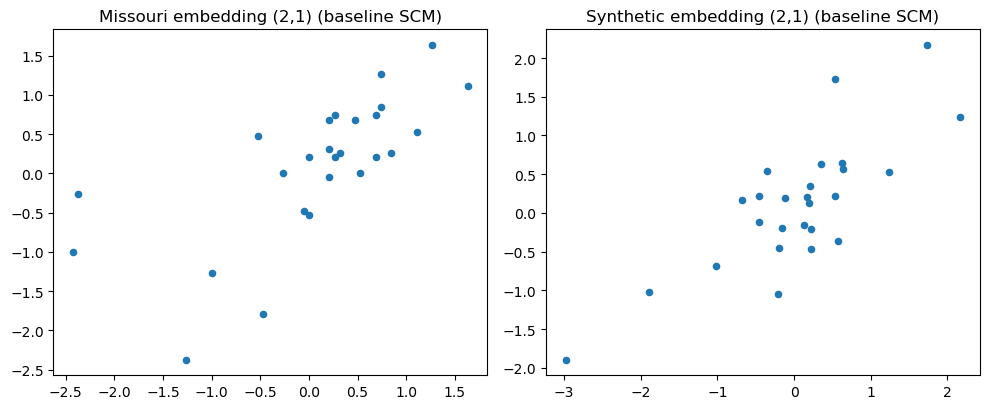

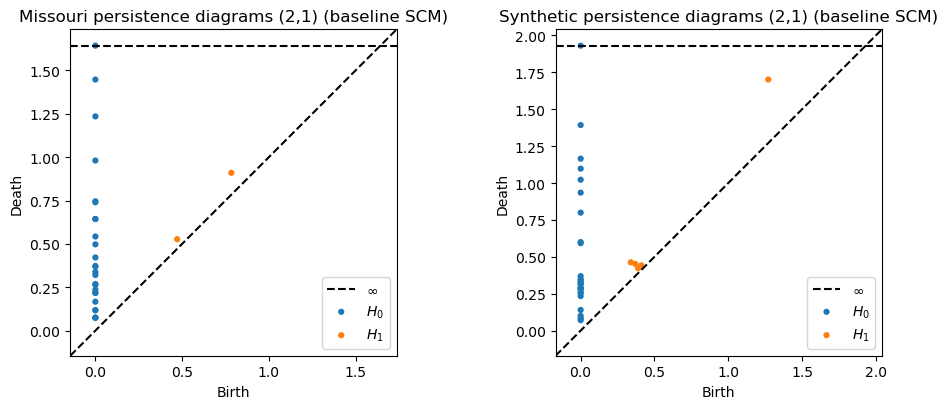

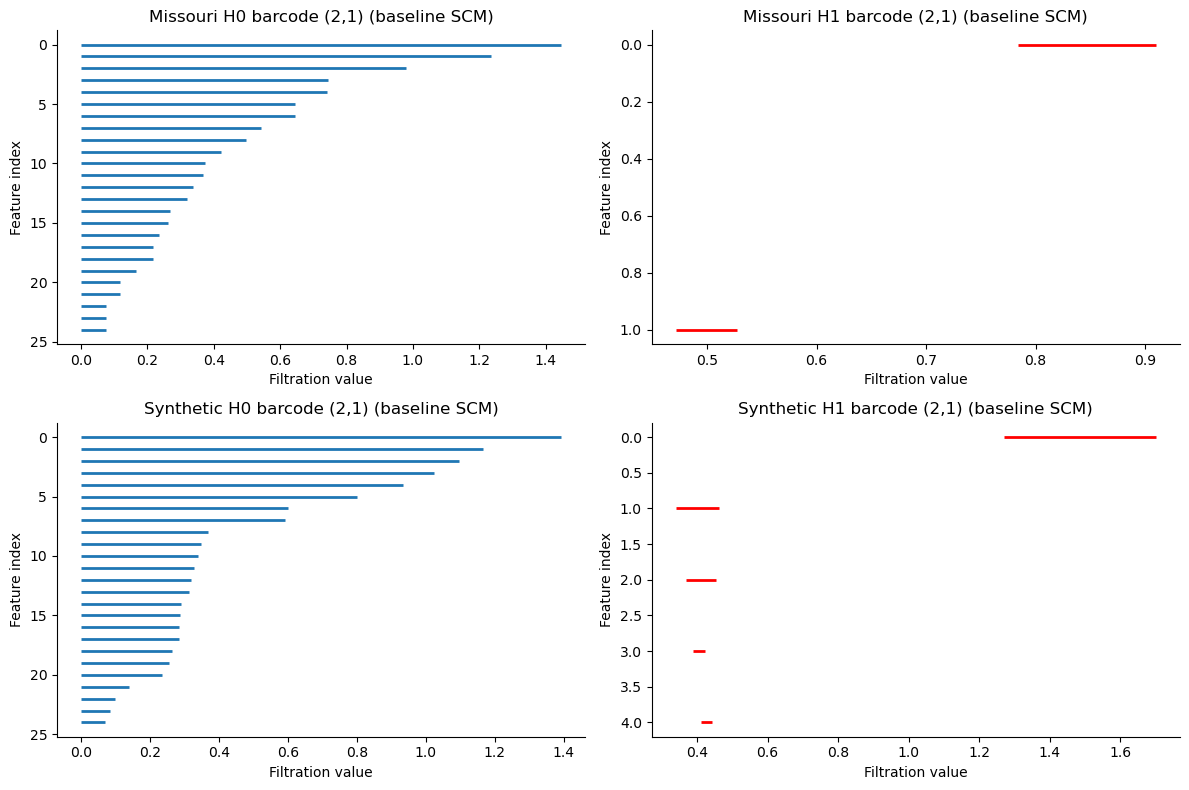


Baseline embedding (2,1) summaries
Missouri H0: {'n_features': 25, 'max_persistence': 1.4472205638885498, 'total_persistence': 11.123986929655075, 'mean_persistence': 0.444959477186203}
Missouri H1: {'n_features': 2, 'max_persistence': 0.12631350755691528, 'total_persistence': 0.1819554567337036, 'mean_persistence': 0.0909777283668518}
Synthetic H0: {'n_features': 25, 'max_persistence': 1.3926331996917725, 'total_persistence': 11.909094542264938, 'mean_persistence': 0.4763637816905975}
Synthetic H1: {'n_features': 5, 'max_persistence': 0.42984652519226074, 'total_persistence': 0.7004926204681396, 'mean_persistence': 0.14009852409362794}
H0 bottleneck : 0.277116596698761
H0 wasserstein: 1.732754036784172
H1 bottleneck : 0.21492326259613037
H1 wasserstein: 0.6239850194344537

=== BASELINE EMBEDDING SUMMARY TABLE ===
embedding  dim  delay  n_points  H0_bottleneck  H0_wasserstein  H1_bottleneck  H1_wasserstein  MO_H0_n  MO_H0_maxpers  MO_H0_totalpers  MO_H0_meanpers  SYN_H0_n  SYN_H0_maxp

In [1]:
# ============================================================
# 04_baseline_tda
# Purpose:
#   - load baseline_df from 03_baseline_scm
#   - build pre-treatment standardized level series
#   - run TDA for baseline SCM using:
#       (3,1) main specification
#       (2,1) robustness specification
#   - save all plots as PDF
#   - save summary table as CSV
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams, bottleneck, wasserstein

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
INPUT_DIR = "outputs_baseline"
OUTPUT_DIR = "outputs_baseline_tda"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASELINE_DF_PATH = os.path.join(INPUT_DIR, "baseline_df.csv")

# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
baseline_df = pd.read_csv(BASELINE_DF_PATH)
baseline_df["date"] = pd.to_datetime(baseline_df["date"])

print("Loaded baseline_df:")
print(baseline_df.head())
print("\nColumns:", baseline_df.columns.tolist())

if "treated" not in baseline_df.columns:
    raise ValueError("Cannot find 'treated' column in baseline_df.")

if "synthetic_baseline" not in baseline_df.columns:
    raise ValueError("Cannot find 'synthetic_baseline' column in baseline_df.")

# ------------------------------------------------------------
# 2) Basic settings
# ------------------------------------------------------------
treatment_start = pd.Timestamp("2011-04-01")

# ------------------------------------------------------------
# 3) Extract pre-treatment levels
# ------------------------------------------------------------
pre_levels = baseline_df.loc[
    baseline_df["date"] < treatment_start,
    ["date", "treated", "synthetic_baseline"]
].copy()

pre_levels = pre_levels.rename(columns={"synthetic_baseline": "synthetic"})
pre_levels = pre_levels.sort_values("date").reset_index(drop=True)

print("\nPretreatment sample:")
print("  first date:", pre_levels["date"].min().date())
print("  last  date:", pre_levels["date"].max().date())
print("  n periods :", len(pre_levels))

pre_levels.to_csv(os.path.join(OUTPUT_DIR, "baseline_pre_levels.csv"), index=False)

# ------------------------------------------------------------
# 4) Standardize each series separately
# ------------------------------------------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=0)
    if s == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / s

pre_levels["treated_z"] = zscore(pre_levels["treated"])
pre_levels["synthetic_z"] = zscore(pre_levels["synthetic"])

pre_levels.to_csv(os.path.join(OUTPUT_DIR, "baseline_pre_levels_standardized.csv"), index=False)

# ------------------------------------------------------------
# 5) Plot standardized level series
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(pre_levels["date"], pre_levels["treated_z"], label="Missouri", linewidth=1.8)
ax.plot(pre_levels["date"], pre_levels["synthetic_z"], label="Synthetic control (baseline SCM)", linewidth=1.8)
ax.axhline(0, color="lightgray", linewidth=1)

ax.set_title("Pre-treatment Standardized Level Series (Baseline SCM)")
ax.set_ylabel("Standardized value")
ax.set_xlabel("Date")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "baseline_standardized_pre_series.pdf"),
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 6) Delay embedding helper
# ------------------------------------------------------------
def delay_embed(x, dim=3, delay=1):
    x = np.asarray(x, dtype=float)
    n = len(x) - (dim - 1) * delay
    if n <= 0:
        raise ValueError(
            f"Series too short for requested embedding: len={len(x)}, dim={dim}, delay={delay}"
        )
    return np.column_stack([x[i:i+n] for i in range(0, dim * delay, delay)])

# ------------------------------------------------------------
# 7) TDA helper functions
# ------------------------------------------------------------
def finite_diagram(dgm):
    dgm = np.asarray(dgm, dtype=float)
    if dgm.size == 0:
        return dgm.reshape(0, 2)
    return dgm[np.isfinite(dgm[:, 1])]

def persistence_summary(dgm):
    dgm = np.asarray(dgm, dtype=float)
    if dgm.size == 0:
        return {
            "n_features": 0,
            "max_persistence": 0.0,
            "total_persistence": 0.0,
            "mean_persistence": 0.0
        }

    pers = dgm[:, 1] - dgm[:, 0]
    pers = pers[np.isfinite(pers)]

    if len(pers) == 0:
        return {
            "n_features": 0,
            "max_persistence": 0.0,
            "total_persistence": 0.0,
            "mean_persistence": 0.0
        }

    return {
        "n_features": int(len(pers)),
        "max_persistence": float(np.max(pers)),
        "total_persistence": float(np.sum(pers)),
        "mean_persistence": float(np.mean(pers))
    }

def plot_single_barcode(ax, dgm, title="Persistent barcode", color="C0"):
    dgm = np.asarray(dgm, dtype=float)

    if dgm.size == 0:
        ax.set_title(title)
        ax.text(
            0.5, 0.5, "No finite features",
            ha="center", va="center", transform=ax.transAxes
        )
        ax.set_xlabel("Filtration value")
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        return

    pers = dgm[:, 1] - dgm[:, 0]
    order = np.argsort(-pers)
    dgm = dgm[order]

    for i, (birth, death) in enumerate(dgm):
        ax.hlines(i, birth, death, linewidth=2, color=color)

    xmin, xmax = np.min(dgm[:, 0]), np.max(dgm[:, 1])
    pad = 0.05 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title)
    ax.set_xlabel("Filtration value")
    ax.set_ylabel("Feature index")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 8) Embedding specifications
# Only main + robustness
# ------------------------------------------------------------
embedding_specs = [
    (3, 1),  # main
    (2, 1),  # robustness
]

summary_rows = []

# ------------------------------------------------------------
# 9) Run each embedding
# ------------------------------------------------------------
for embed_dim, embed_delay in embedding_specs:
    emb_label = f"({embed_dim},{embed_delay})"
    emb_tag = f"{embed_dim}_{embed_delay}"

    print("\n" + "=" * 70)
    print(f"Running baseline embedding {emb_label}")
    print("=" * 70)

    # --------------------------------------------------------
    # 9.1 Build point clouds
    # --------------------------------------------------------
    treated_pc = delay_embed(pre_levels["treated_z"], dim=embed_dim, delay=embed_delay)
    synthetic_pc = delay_embed(pre_levels["synthetic_z"], dim=embed_dim, delay=embed_delay)

    print("treated point cloud shape  :", treated_pc.shape)
    print("synthetic point cloud shape:", synthetic_pc.shape)

    pd.DataFrame(treated_pc).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_treated_embedding_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(synthetic_pc).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_synthetic_embedding_{emb_tag}.csv"),
        index=False
    )

    # --------------------------------------------------------
    # 9.2 Plot embedding scatter
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    axes[0].scatter(treated_pc[:, 0], treated_pc[:, 1], s=20)
    axes[0].set_title(f"Missouri embedding {emb_label} (baseline SCM)")

    axes[1].scatter(synthetic_pc[:, 0], synthetic_pc[:, 1], s=20)
    axes[1].set_title(f"Synthetic embedding {emb_label} (baseline SCM)")

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"baseline_embedding_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.3 Persistent homology
    # --------------------------------------------------------
    treated_ph = ripser(treated_pc, maxdim=1)
    synthetic_ph = ripser(synthetic_pc, maxdim=1)

    treated_dgm0, treated_dgm1 = treated_ph["dgms"]
    synthetic_dgm0, synthetic_dgm1 = synthetic_ph["dgms"]

    pd.DataFrame(treated_dgm0, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_treated_H0_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(treated_dgm1, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_treated_H1_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(synthetic_dgm0, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_synthetic_H0_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(synthetic_dgm1, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_synthetic_H1_diagram_{emb_tag}.csv"),
        index=False
    )

    # --------------------------------------------------------
    # 9.4 Plot persistence diagrams
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    plot_diagrams([treated_dgm0, treated_dgm1], ax=axes[0], show=False)
    axes[0].set_title(f"Missouri persistence diagrams {emb_label} (baseline SCM)")

    plot_diagrams([synthetic_dgm0, synthetic_dgm1], ax=axes[1], show=False)
    axes[1].set_title(f"Synthetic persistence diagrams {emb_label} (baseline SCM)")

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"baseline_persistence_diagrams_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.5 Finite diagrams
    # --------------------------------------------------------
    treated_dgm0_f = finite_diagram(treated_dgm0)
    treated_dgm1_f = finite_diagram(treated_dgm1)
    synthetic_dgm0_f = finite_diagram(synthetic_dgm0)
    synthetic_dgm1_f = finite_diagram(synthetic_dgm1)

    # --------------------------------------------------------
    # 9.6 Plot barcodes
    # --------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    plot_single_barcode(
        axes[0, 0], treated_dgm0_f,
        title=f"Missouri H0 barcode {emb_label} (baseline SCM)", color="C0"
    )
    plot_single_barcode(
        axes[1, 0], synthetic_dgm0_f,
        title=f"Synthetic H0 barcode {emb_label} (baseline SCM)", color="C0"
    )

    plot_single_barcode(
        axes[0, 1], treated_dgm1_f,
        title=f"Missouri H1 barcode {emb_label} (baseline SCM)", color="red"
    )
    plot_single_barcode(
        axes[1, 1], synthetic_dgm1_f,
        title=f"Synthetic H1 barcode {emb_label} (baseline SCM)", color="red"
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"baseline_barcodes_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.7 Summaries
    # --------------------------------------------------------
    mo_h0 = persistence_summary(treated_dgm0_f)
    mo_h1 = persistence_summary(treated_dgm1_f)
    syn_h0 = persistence_summary(synthetic_dgm0_f)
    syn_h1 = persistence_summary(synthetic_dgm1_f)

    h0_bottle = bottleneck(treated_dgm0_f, synthetic_dgm0_f)
    h0_wass = wasserstein(treated_dgm0_f, synthetic_dgm0_f)
    h1_bottle = bottleneck(treated_dgm1_f, synthetic_dgm1_f)
    h1_wass = wasserstein(treated_dgm1_f, synthetic_dgm1_f)

    print(f"\nBaseline embedding {emb_label} summaries")
    print("Missouri H0:", mo_h0)
    print("Missouri H1:", mo_h1)
    print("Synthetic H0:", syn_h0)
    print("Synthetic H1:", syn_h1)
    print("H0 bottleneck :", h0_bottle)
    print("H0 wasserstein:", h0_wass)
    print("H1 bottleneck :", h1_bottle)
    print("H1 wasserstein:", h1_wass)

    summary_rows.append({
        "embedding": emb_label,
        "dim": embed_dim,
        "delay": embed_delay,
        "n_points": treated_pc.shape[0],

        "H0_bottleneck": h0_bottle,
        "H0_wasserstein": h0_wass,
        "H1_bottleneck": h1_bottle,
        "H1_wasserstein": h1_wass,

        "MO_H0_n": mo_h0["n_features"],
        "MO_H0_maxpers": mo_h0["max_persistence"],
        "MO_H0_totalpers": mo_h0["total_persistence"],
        "MO_H0_meanpers": mo_h0["mean_persistence"],

        "SYN_H0_n": syn_h0["n_features"],
        "SYN_H0_maxpers": syn_h0["max_persistence"],
        "SYN_H0_totalpers": syn_h0["total_persistence"],
        "SYN_H0_meanpers": syn_h0["mean_persistence"],

        "MO_H1_n": mo_h1["n_features"],
        "MO_H1_maxpers": mo_h1["max_persistence"],
        "MO_H1_totalpers": mo_h1["total_persistence"],
        "MO_H1_meanpers": mo_h1["mean_persistence"],

        "SYN_H1_n": syn_h1["n_features"],
        "SYN_H1_maxpers": syn_h1["max_persistence"],
        "SYN_H1_totalpers": syn_h1["total_persistence"],
        "SYN_H1_meanpers": syn_h1["mean_persistence"],
    })

# ------------------------------------------------------------
# 10) Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)

print("\n=== BASELINE EMBEDDING SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_embedding_summary.csv"),
    index=False
)

with open(os.path.join(OUTPUT_DIR, "baseline_embedding_summary.txt"), "w", encoding="utf-8") as f:
    f.write("=== BASELINE EMBEDDING SUMMARY TABLE ===\n")
    f.write(summary_df.to_string(index=False))

print(f"\nSaved outputs in: {OUTPUT_DIR}")
print(" - baseline_pre_levels.csv")
print(" - baseline_pre_levels_standardized.csv")
print(" - baseline_standardized_pre_series.pdf")
print(" - baseline_embedding_summary.csv")
print(" - baseline_embedding_summary.txt")
print(" - baseline_embedding_3_1.pdf")
print(" - baseline_embedding_2_1.pdf")
print(" - baseline_persistence_diagrams_3_1.pdf")
print(" - baseline_persistence_diagrams_2_1.pdf")
print(" - baseline_barcodes_3_1.pdf")
print(" - baseline_barcodes_2_1.pdf")
print(" - per-embedding point-cloud and diagram csvs")